# Computer Vision (Image operators and filters)

By the end of this lab, you will get hands on experience working with:

*   Image Handling
*   Image Manipulation
*   Histogram and Histogram Equalization
*   Basic filtering techniques

<!-- ### **Remember this is a graded exercise.** -->

**Reminder**:

*   For every plot, make sure you provide appropriate titles, axis labels, legends, wherever applicable.
*   Add sufficient comments and explanations wherever necessary.

---


In [1]:
# Loading necessary libraries (Feel free to add new libraries if you need for any computation)

import numpy as np
from matplotlib import pyplot as plt
from skimage import data, exposure, filters, io, morphology 

# Channels and color spaces

### **Exercise: Image Creation and Color Manipulation**

*   Create a 100 x 100 image for each of the below visualization

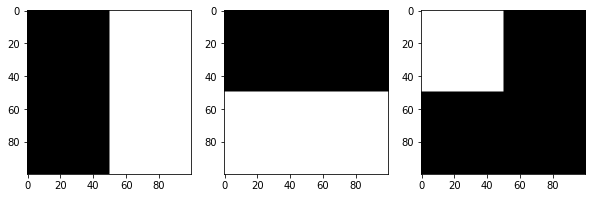

*   Visualize the created images in a 1 x 3 subplot using matplotlib.


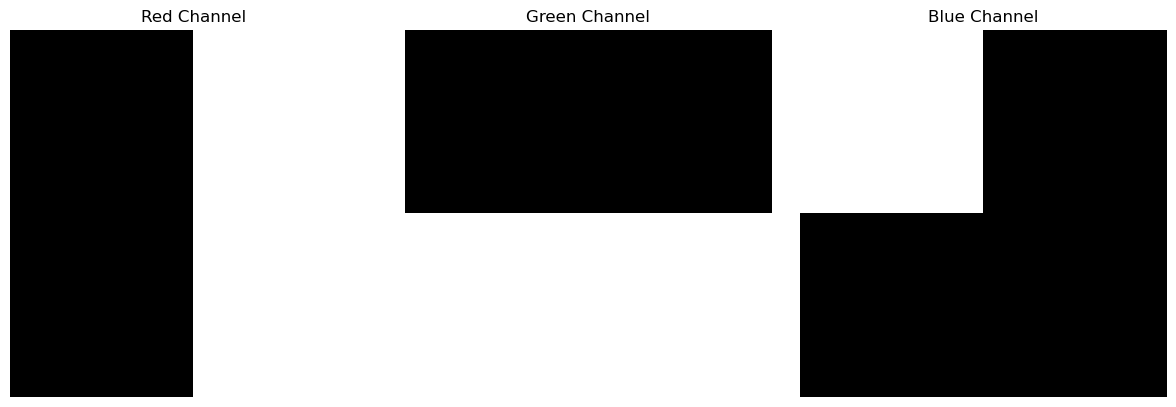

In [4]:

# 1. Create the Red channel image (left half black, right half white)
red_channel = np.zeros((100, 100), dtype=np.uint8)
red_channel[:, 50:100] = 255 

# 2. Create the Green channel image (top half black, bottom half white)
green_channel = np.zeros((100, 100), dtype=np.uint8)
green_channel[50:100, : ] = 255  

# 3. Create the Blue channel image (top-left quadrant white, rest black)
blue_channel = np.zeros((100, 100), dtype=np.uint8)
blue_channel[:50, :50] = 255 

# Create the figure and a 1x3 panel of axes
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# 1. Plot the Red Channel in the first panel
axes[0].imshow(red_channel, cmap='gray')
axes[0].set_title("Red Channel")
axes[0].axis('off')

# 2. Plot the Green Channel in the second panel
axes[1].imshow(green_channel, cmap='gray')
axes[1].set_title("Green Channel")
axes[1].axis('off')

# 3. Plot the Blue Channel in the third panel
axes[2].imshow(blue_channel, cmap='gray')
axes[2].set_title("Blue Channel")
axes[2].axis('off')

# Render the plots nicely
plt.tight_layout()
plt.show()


*   Use the above three images to create the following image

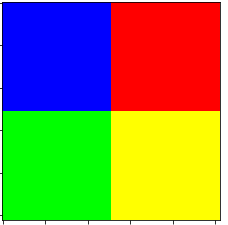
*Hint: Remember channels and color spaces*

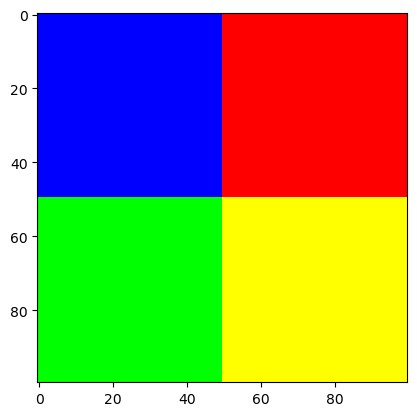

In [6]:
color_image = np.dstack((red_channel, green_channel, blue_channel))

plt.imshow(color_image)


### **Exercise: Color Manipulation**

*   Read the image 'sillas.jpg' from the images folder

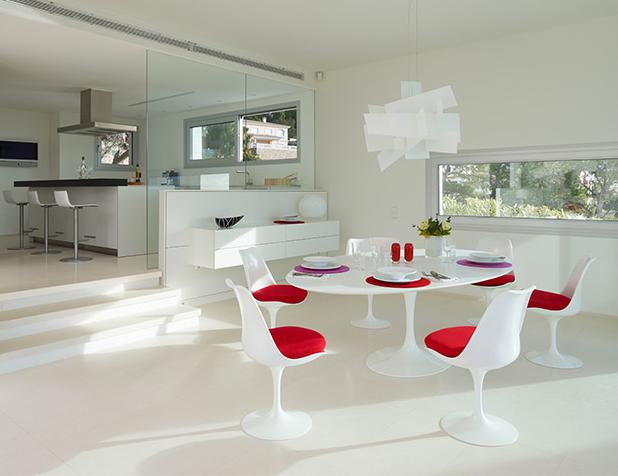

*   Extract individual channels and plot them using matplotlib subplot.



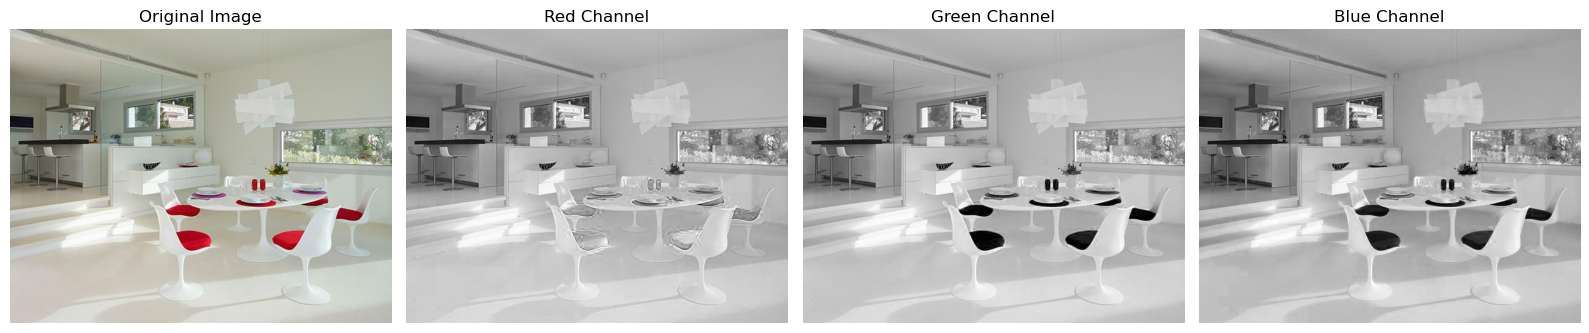

In [8]:
# 1. Read the image using skimage.io
image = io.imread('images/sillas.jpg')

# 2. Extract individual channels
red_channel = image[:, :, 0]
green_channel = image[:, :, 1]  
blue_channel = image[:, :, 2]   

# 3. Plot the original image and the three channels in a 1x4 subplot
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Panel 0: Original color image
axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis('off')

# Panel 1: Red Channel
axes[1].imshow(red_channel, cmap='gray')
axes[1].set_title("Red Channel")
axes[1].axis('off')

# Panel 2: Green Channel
axes[2].imshow(green_channel, cmap='gray')
axes[2].set_title("Green Channel")
axes[2].axis('off')

# Panel 3: Blue Channel
axes[3].imshow(blue_channel, cmap='gray')
axes[3].set_title("Blue Channel")
axes[3].axis('off')

plt.tight_layout()
plt.show()

*   The color **red** looks too bright for the eyes. Isn't it?? Lets change the color and see how it appears.
    *    Create a new image where everything that is **'red' is changed to 'blue'**.
*   Visualize the original image and the created image using matplotlib subplot.

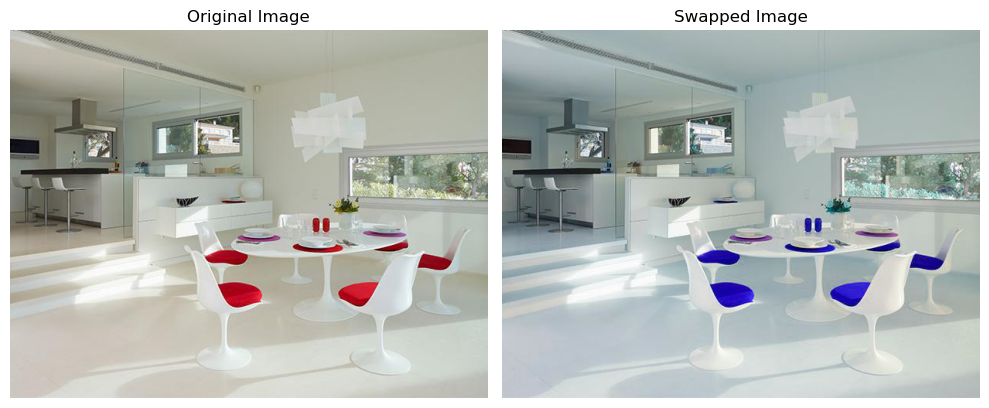

In [ ]:
# 1. Swap the Red and Blue channels to turn Red into Blue
swapped_image = np.dstack((blue_channel, green_channel, red_channel))

# 2. Visualize the original and swapped images side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Panel 0: Original Image
axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis('off')

# Panel 1: Red-to-Blue Swapped Image
axes[1].imshow(swapped_image)
axes[1].set_title("Swapped Image")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Image Manipulation

### **Exercise: Image Operators**

*   You can find images 'model.png' and 'coat.png' in the images folder (First two images of the below visualization). Your task is to create an image from the given two images such a way that the model is wearing the coat (Third image in the visualization).
*   You can also find different textures in the images folder. Your task is to change the coat texture to any one of the given textures.
*   Visualize the images similar to the given visualization.

*Hint: Think masks!!!*

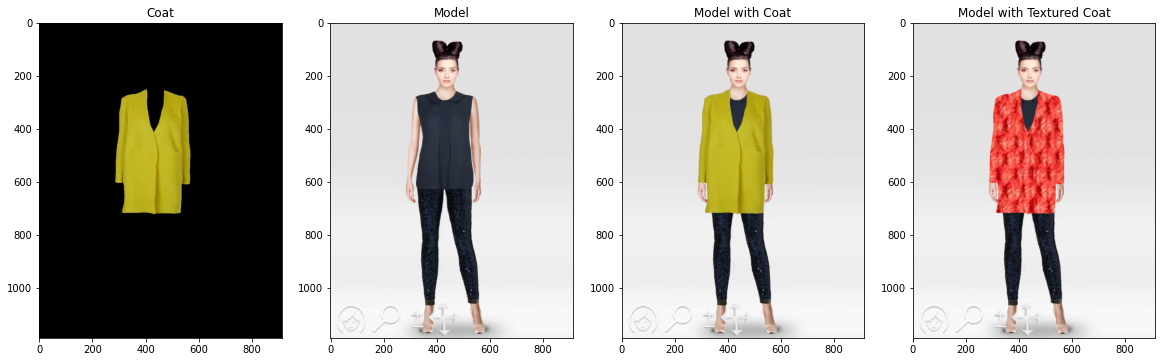

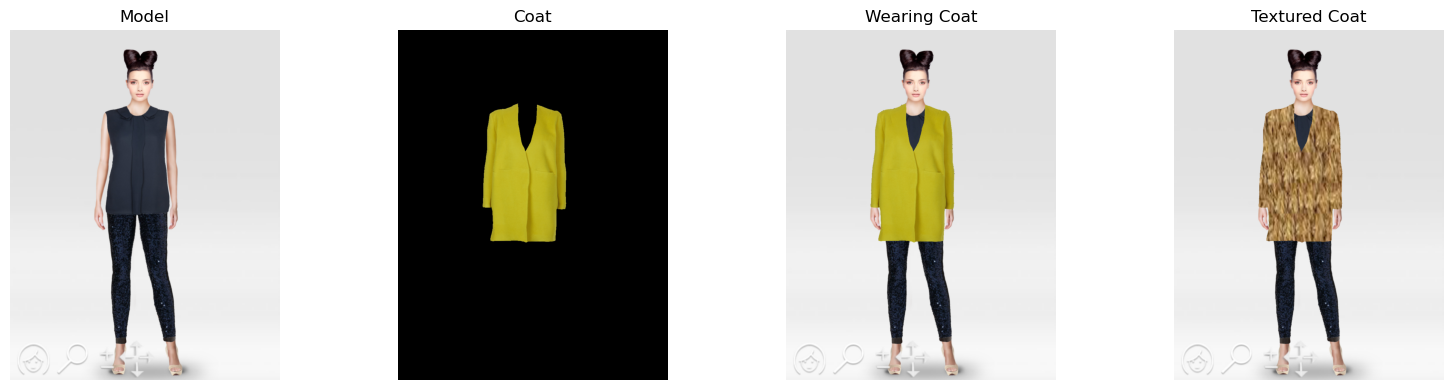

In [ ]:
from skimage import io
from skimage.transform import resize
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the images
model = io.imread('images/model.png')
coat = io.imread('images/coat.png')
texture = io.imread('images/texture.png')

# 2. Extract RGB channels (discarding any alpha channel if present)
model_rgb = model[:, :, :3]
coat_rgb = coat[:, :, :3]

# 3. Create the coat mask
coat_mask = np.any(coat_rgb > 0, axis=-1)

# Task 1: Model wearing the coat
model_wearing_coat = model_rgb.copy()
model_wearing_coat[coat_mask] = coat_rgb[coat_mask]

# Task 2: Model wearing the textured coat
h, w, _ = model_rgb.shape
resized_texture = resize(texture, (h, w, 3), preserve_range=True).astype(np.uint8)

model_wearing_textured_coat = model_rgb.copy()
model_wearing_textured_coat[coat_mask] = resized_texture[coat_mask]

# 4. Plot the results in a 1x4 subplot
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(model_rgb)
axes[0].set_title("Model")
axes[0].axis('off')

axes[1].imshow(coat_rgb)
axes[1].set_title("Coat")
axes[1].axis('off')

# Display Task 1 in the third panel
axes[2].imshow(model_wearing_coat)
axes[2].set_title("Wearing Coat")
axes[2].axis('off')

# Display Task 2 in the fourth panel
axes[3].imshow(model_wearing_textured_coat)
axes[3].set_title("Textured Coat")
axes[3].axis('off')

plt.tight_layout()
plt.show()


# Contrast Enhancement

### **Exercise: Histogram Computation**

*   Read the **'astronaut' image** from data module.
*   Convert the image to grayscale.
*   Compute the **histogram of the image.** *Hint: histogram function is available in skimage.exposure package*
*   Plot the histogram using matplotlib plot.




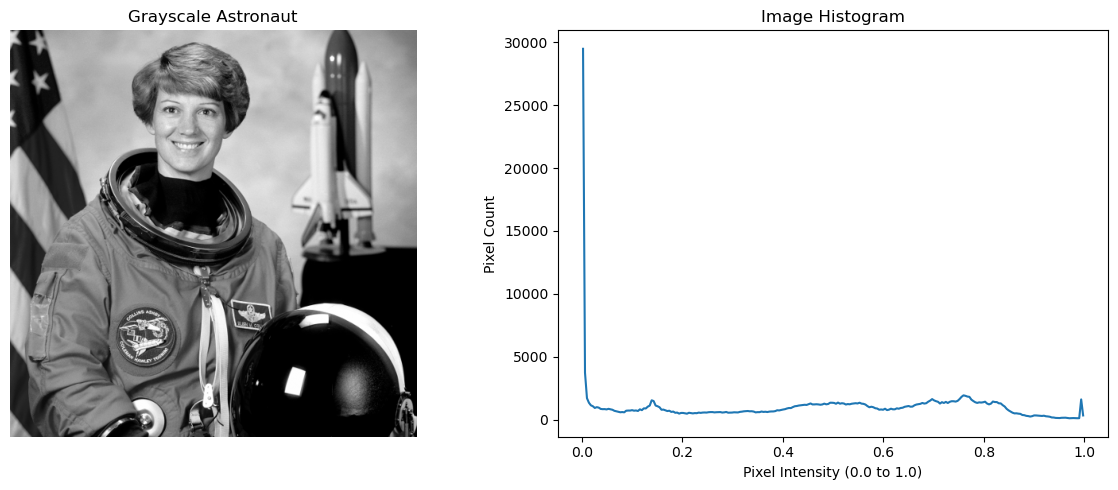

In [ ]:
from skimage import data, exposure, color
import matplotlib.pyplot as plt

# 1. Read the 'astronaut' image
astronaut_image = data.astronaut()

# 2. Convert the image to grayscale
gray_astronaut = color.rgb2gray(astronaut_image)

# 3. Compute the histogram of the image
hist, bin_centers = exposure.histogram(gray_astronaut)


# 4. Plot the results in a 1x2 subplot (Original vs Histogram)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel 0: The Grayscale Image
axes[0].imshow(gray_astronaut, cmap='gray')
axes[0].set_title("Grayscale Astronaut")
axes[0].axis('off')

# Panel 1: The Histogram Plot
axes[1].plot(bin_centers, hist)
axes[1].set_title("Image Histogram")
axes[1].set_xlabel("Pixel Intensity (0.0 to 1.0)")
axes[1].set_ylabel("Pixel Count")

plt.tight_layout()
plt.show()

*   Change the bin count to 8 and compute the histogram of the image and plot the computed histogram using matplotlib plot.

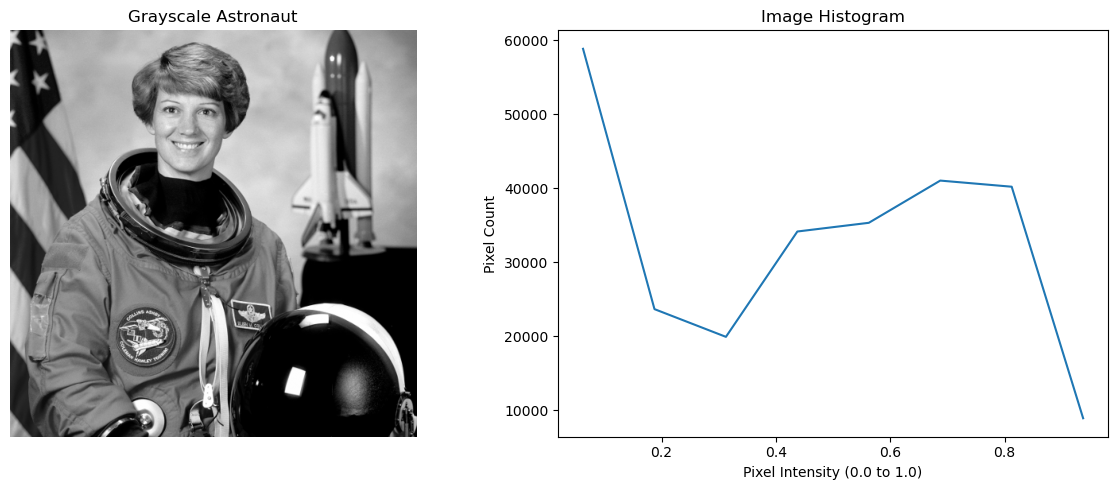

In [22]:
from skimage import data, exposure, color
import matplotlib.pyplot as plt

# 1. Read the 'astronaut' image
astronaut_image = data.astronaut()

# 2. Convert the image to grayscale
gray_astronaut = color.rgb2gray(astronaut_image)

# 3. Compute the histogram of the image
hist, bin_centers = exposure.histogram(gray_astronaut, nbins=8)


# 4. Plot the results in a 1x2 subplot (Original vs Histogram)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel 0: The Grayscale Image
axes[0].imshow(gray_astronaut, cmap='gray')
axes[0].set_title("Grayscale Astronaut")
axes[0].axis('off')

# Panel 1: The Histogram Plot
axes[1].plot(bin_centers, hist)
axes[1].set_title("Image Histogram")
axes[1].set_xlabel("Pixel Intensity (0.0 to 1.0)")
axes[1].set_ylabel("Pixel Count")

plt.tight_layout()
plt.show()




*   What happens when you change the bin count? Does your inference change based on the bin count? If yes, then how do you define the correct bin count.
*   What happens when the bin count is very low and what happens when it is very high?



In [23]:
# If you have the bins set too high you can not see the detail in the graph. If they are too low it become a simple linear regression. 